# Notebook for comparing PV yields between pvlib as used in the model and HOMER Pro

Coordinates, tilt, temperature adjustment, and other variables must be identical

Homer Pro
* Use NREL solar resource for coordinates 40.7128, -74.0060
* Generic flat plate PV
    * temperature coef = -0.3
    * module efficiency = 13%
    * derating = 86%
    * ground reflectance = 25%
* Off-grid
    * PV is on DC bus
    * derating = 85%
    * mppt efficiency = 99%
    * mppt size = 1.2kW (just needs to be maximum used in model)
* Plug-in
    * PV is on AC bus for microgrid configuration
    * inverter efficiency = 95%
    * the inverter capacity is 500W for <=500W systems & 1200W for <=1200W systems

In [94]:
import pandas as pd
import numpy as np
import requests
import pvlib
import matplotlib.pyplot as plt  # for visualization
import math
from datetime import datetime
from statistics import median
from statistics import mean

import sys
sys.path.append('..')
from keys import *

In [95]:
#GLOBALS
#note that these coordinates are the inputs for the NREL API,
#the coordinates used by the NREL API for the weather file are slightly different
#see below
lat = 40.7128
long = -74.0060

#optimize for summer when DR program is in effect
#also minimizes shading from buildings during PSH
tilt = lat #math.floor(lat - 15)
print("tilt: " + str(tilt))

#default to south facing
azimuth = 180

#14% losses
shading = .86

#max 99% efficient mppt battery charger - used for PV to battery
mppt = .99

# conversion rate when charging battery from grid - used for grid to battery
acToDC = .9

# microinverter conversion efficiency - used for PV to grid
# Device: Hoymiles HiFlow (360-500) Pro LV
miEff = 0.998 #nominal efficiency
#miMaxW = 470 #max input wattage
miMaxW_hm = 500 #max input wattage for Hoymiles microinverter
miMaxW_ap = 1200 #max input wattage for AP microinverter

# max 80% depth of discharge for LiFePO4 batteries under normal circumstances
# & 95% to maximize flexibiltiy during events
LiFePOdod = 0.80
LiFePOdod_event = 0.95

#Max Hardware Sizes
pvMaxW = 1200

#PV degredation rate is assumed to be 1% annually
DEG_RATE = 0.01

#days in the months May - September
daysInMonth = [31,30,31,31,30]
drSeasonStartDay = 121

# self consumption of both controller and power station
controllerSC = 1 #Raspberry Pi Zero 2W controller self-consumption
powerStationSC = 8.62 #power station no-load self-consumption with AC outputs turned on
scWDC = controllerSC + powerStationSC
dailySelfConsumptionWhDC = scWDC * 24
#annualSelfConsumptionkWhDC = scWDC * 24 * 365 * 0.001


tilt: 40.7128


# PV Modeling

In [96]:
#get TMY via API
try:
    df_tmy, metadata = pvlib.iotools.get_nsrdb_psm4_tmy(
        latitude=lat,
        longitude=long,
        api_key=NREL_API_KEY,
        time_step=60,
        email='nathaa@rpi.edu',  # <-- any email works here fine
        year='tmy-2024')
except requests.HTTPError as e:
    print("Status code:", e.response.status_code)
    print("Raw response text:")
    print(e.response.text)
    raise

metadata

{'Source': 'NSRDB',
 'Location ID': '1243965',
 'City': '-',
 'State': '-',
 'Country': '-',
 'Time Zone': -5,
 'Local Time Zone': -5,
 'Clearsky DHI Units': 'w/m2',
 'Clearsky DNI Units': 'w/m2',
 'Clearsky GHI Units': 'w/m2',
 'Dew Point Units': 'c',
 'DHI Units': 'w/m2',
 'DNI Units': 'w/m2',
 'GHI Units': 'w/m2',
 'Solar Zenith Angle Units': 'Degree',
 'Temperature Units': 'c',
 'Pressure Units': 'mbar',
 'Relative Humidity Units': '%',
 'Precipitable Water Units': 'cm',
 'Wind Direction Units': 'Degrees',
 'Wind Speed Units': 'm/s',
 'Cloud Type -15': 'N/A',
 'Cloud Type 0': 'Clear',
 'Cloud Type 1': 'Probably Clear',
 'Cloud Type 2': 'Fog',
 'Cloud Type 3': 'Water',
 'Cloud Type 4': 'Super-Cooled Water',
 'Cloud Type 5': 'Mixed',
 'Cloud Type 6': 'Opaque Ice',
 'Cloud Type 7': 'Cirrus',
 'Cloud Type 8': 'Overlapping',
 'Cloud Type 9': 'Overshooting',
 'Cloud Type 10': 'Unknown',
 'Cloud Type 11': 'Dust',
 'Cloud Type 12': 'Smoke',
 'Fill Flag 0': 'N/A',
 'Fill Flag 1': 'Missing I

In [97]:
#df_tmy.to_csv("data/tmy_2024_NYC.csv", index=True)

In [98]:
# make a Location object corresponding to this TMY
location = pvlib.location.Location(name='NYC',
                                   latitude=metadata['latitude'],
                                   longitude=metadata['longitude'])

location

Location: 
  name: NYC
  latitude: 40.73
  longitude: -74.02
  altitude: -2.0
  tz: UTC

In [99]:
#normalize all years to 2020
#remove timezone info #,tzinfo=None
df_tmy.index = df_tmy.index.map(lambda t: t.replace(year=2020))

#uncomment the 30 minute shifts if using data that is right-labeled at hourly intervals!
# Note: TMY datasets are right-labeled hourly intervals, e.g. the
# 10AM to 11AM interval is labeled 11.  We should calculate solar position in
# the middle of the interval (10:30), so we subtract 30 minutes:
times = df_tmy.index #- pd.Timedelta('30min')
solar_position = location.get_solarposition(times)
# but remember to shift the index back to line up with the TMY data:
#solar_position.index += pd.Timedelta('30min')

solar_position

,apparent_zenith,zenith,apparent_elevation,elevation,azimuth,equation_of_time
2020-01-01 00:30:00-05:00,161.167644,161.167644,-71.167644,-71.167644,22.397593,-3.190860
2020-01-01 01:30:00-05:00,154.001161,154.001161,-64.001161,-64.001161,54.029306,-3.210673
2020-01-01 02:30:00-05:00,143.834623,143.834623,-53.834623,-53.834623,72.365773,-3.230477
2020-01-01 03:30:00-05:00,132.705852,132.705852,-42.705852,-42.705852,84.714658,-3.250272
2020-01-01 04:30:00-05:00,121.355180,121.355180,-31.355180,-31.355180,94.580427,-3.270057
...,...,...,...,...,...,...
2020-12-31 19:30:00-05:00,121.549755,121.549755,-31.549755,-31.549755,265.621718,-3.441097
2020-12-31 20:30:00-05:00,132.896245,132.896245,-42.896245,-42.896245,275.528481,-3.460697
2020-12-31 21:30:00-05:00,144.009842,144.009842,-54.009842,-54.009842,287.965009,-3.480288
2020-12-31 22:30:00-05:00,154.134861,154.134861,-64.134861,-64.134861,306.489310,-3.499870


In [113]:
# temperature coef
gamma_pdc = -0.003  # divide by 100 to go from %/°C to 1/°C

all_parameters = pvlib.temperature.TEMPERATURE_MODEL_PARAMETERS['sapm']
parameters = all_parameters['open_rack_glass_polymer']

# #args: tilt, azimuth
# def getPOA(t,a):
#     #fixed tilt POA
#     df_poa = pvlib.irradiance.get_total_irradiance(
#         surface_tilt=t,
#         surface_azimuth=a,
#         dni=df_tmy['dni'],
#         ghi=df_tmy['ghi'],
#         dhi=df_tmy['dhi'],
#         solar_zenith=solar_position['apparent_zenith'],
#         solar_azimuth=solar_position['azimuth'],
#         model='isotropic')

#     #print(df_poa.keys())
#     return df_poa

#updated 9/17/2026
def getPOA(t, a):
    dni_extra = pvlib.irradiance.get_extra_radiation(df_tmy.index)
    airmass = pvlib.atmosphere.get_relative_airmass(solar_position['apparent_zenith'])

    df_poa = pvlib.irradiance.get_total_irradiance(
        surface_tilt=t, surface_azimuth=a,
        dni=df_tmy['dni'], ghi=df_tmy['ghi'], dhi=df_tmy['dhi'],
        solar_zenith=solar_position['apparent_zenith'],
        solar_azimuth=solar_position['azimuth'],
        dni_extra=dni_extra, airmass=airmass,
        model='perez')   # formerly used isotropic

    df_poa['poa_sky_diffuse'] = df_poa['poa_sky_diffuse'].fillna(0)
    df_poa['poa_diffuse'] = df_poa['poa_sky_diffuse'] + df_poa['poa_ground_diffuse']
    df_poa['poa_global'] = df_poa['poa_direct'] + df_poa['poa_diffuse']

    df_poa['aoi'] = pvlib.irradiance.aoi(
        surface_tilt=t, surface_azimuth=a,
        solar_zenith=solar_position['apparent_zenith'],
        solar_azimuth=solar_position['azimuth'])

    return df_poa

# #DC power going in to battery after accounting for shading and equipment derating
# #https://pvlib-python.readthedocs.io/en/stable/reference/generated/pvlib.pvsystem.pvwatts_dc.html#
# #args: power, temp coefficient, array nameplate watts
# def getPowerYield(p,g,n):
    
#     # note the "splat" operator "**" which expands the dictionary "parameters"
#     # into a comma separated list of keyword arguments
#     cell_temperature = pvlib.temperature.sapm_cell(
#         p['poa_global'], df_tmy['temp_air'], df_tmy['wind_speed'], **parameters)
    
#     array_power = pd.DataFrame({
#         'power': pvlib.pvsystem.pvwatts_dc(p['poa_global'], cell_temperature, n, g,temp_ref=25.0)
#     })

#     #yieldDC is actual power going in to battery after losses
#     array_power['yieldDC'] = array_power['power'] * shading * mppt

#     #yieldAC is actual power going in to grid after losses
#     array_power['yieldAC'] = pvlib.inverter.pvwatts(array_power['power'] * shading, miMaxW,miEff)
    
#     return array_power
#     #array_power = pvlib.pvsystem.pvwatts_dc(df_poa['poa_global'], cell_temperature, n, g,temp_ref=25.0)

#     #factor in 14% shading losses + 1% mppt losses
#     #return array_power * shading * mppt

#updated 9/19/26
def getPowerYield(p, g, n):#plane of irradiance, gamma, pv nameplate W
    # ASHRAE IAM applied to the direct beam component only
    iam_beam = pvlib.iam.ashrae(p['aoi'])
    effective_irradiance = p['poa_direct'] * iam_beam + p['poa_diffuse']

    cell_temperature = pvlib.temperature.sapm_cell(
        p['poa_global'], df_tmy['temp_air'], df_tmy['wind_speed'], **parameters)

    array_power = pd.DataFrame({
        'power': pvlib.pvsystem.pvwatts_dc(effective_irradiance, cell_temperature, n, g, temp_ref=25.0)
    })

    miMaxW = miMaxW_ap if n > 500 else miMaxW_hm

    array_power['yieldDC'] = array_power['power'] * shading * mppt
    array_power['yieldAC'] = pvlib.inverter.pvwatts(array_power['power'] * shading, miMaxW, miEff)

    return array_power

#returns the degraded power of the array for a given year
#args: PV watts, year, PV degradation rate
def getDegradedP(w,y,dR = DEG_RATE):
    d = 1 - dR
    return w*(d**y)

array_power_yield = getPowerYield(getPOA(tilt,azimuth),gamma_pdc, 100)
array_power_yield.head()

,power,yieldDC,yieldAC
2020-01-01 00:30:00-05:00,0.0,0.0,0.0
2020-01-01 01:30:00-05:00,0.0,0.0,0.0
2020-01-01 02:30:00-05:00,0.0,0.0,0.0
2020-01-01 03:30:00-05:00,0.0,0.0,0.0
2020-01-01 04:30:00-05:00,0.0,0.0,0.0


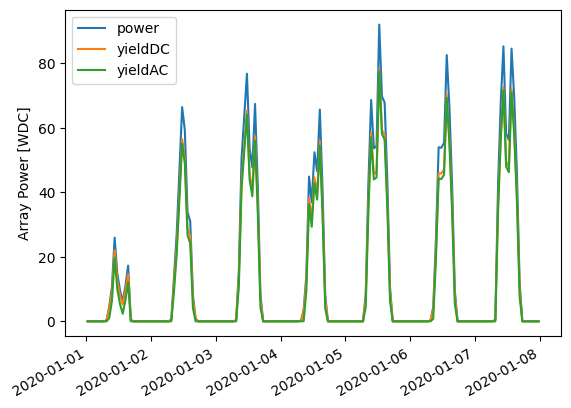

In [114]:
array_power_yield.head(24*7).plot()
plt.ylabel('Array Power [WDC]');

In [115]:
# this function gets yield data for a range of things
def getYieldData(tilt=tilt, gamma_pdc=gamma_pdc, maxPV=pvMaxW, pvInc=50, azimuths=(90,110, 180, 270, 250)):
    """
    Get hourly and daily PV yields for all possible array sizes being modeled,
    at each of the given azimuths.

    Args:
        tilt (float): array tilt angle (degrees).
        gamma_pdc (float): PV temperature coefficient (1/°C).
        maxPV (int): max allowed PV nameplate wattage of any power station
                     in the database (default 1200).
        pvInc (int): increment (W) to step through array sizes (default 50).
        azimuths (iterable of int): azimuth angles to model (default (110, 180, 250)).

    Returns:
        dict: {
            '<azimuth>': {
                '<pW>': {
                    'hourly': <DataFrame from getPowerYield>,
                    'daily': {'dailyDC': [...], 'dailyAC': [...]}
                },
                ...
            },
            ...
        }
    """
    yieldData = {str(a): {} for a in azimuths}

    #print(f'Max PV: {maxPV}')

    for a in azimuths:
        poa = getPOA(tilt, a)

        aData = {}
        for pW in range(pvInc, maxPV + pvInc, pvInc):
            # get hourly power yields for a given array size (W)
            hY = getPowerYield(poa, gamma_pdc, pW)

            # get daily PV yields (Wh)
            # dYDC = []
            # dYAC = []
            # for d in range(365):
            #     dYDC.append(hY['yieldDC'].iloc[d*24:(d*24)+24].sum())
            #     dYAC.append(hY['yieldAC'].iloc[d*24:(d*24)+24].sum())
            dYDC = hY['yieldDC'].to_numpy().reshape(365, 24).sum(axis=1)
            dYAC = hY['yieldAC'].to_numpy().reshape(365, 24).sum(axis=1)

            aData[str(pW)] = {
                'hourly': hY,
                'daily': {'dailyDC': dYDC, 'dailyAC': dYAC}
            }

        yieldData[str(a)] = aData

    return yieldData
    

In [116]:
yieldData = getYieldData()

In [117]:
#yieldData['90']['300']

# Compare HOMER 6x WAC Systems
300W and 1000W at all 3 azimuths

In [118]:
# --- 1. Load both HOMER files ---
def load_homer_csv(path):
    df = pd.read_csv(path, skiprows=1, header=0)
    df = df.drop(index=0).reset_index(drop=True)
    df["Time"] = pd.to_datetime(df["Time"])
    df = df.set_index("Time")
    df = df.apply(pd.to_numeric, errors="coerce")
    return df

df_homer_ac = load_homer_csv("pvWAC_v5.csv")
df_homer_dc = load_homer_csv("pvWDC_v5.csv")

# --- 2. Map each HOMER system to its pvlib (azimuth, wattage, coupling) key ---
# Column names already include the _ac/_dc suffix (e.g. "PV300s_ac Power Output"),
# so no name-stripping is needed. Some systems only exist in one file
# (PV1000w/PV1000e appear to be split one-per-coupling), while the rest
# appear as reference columns in both files — so look them up with a fallback.
system_map = {
    "PV300s_ac":  (180, 300,  "ac"),
    "PV1000s_ac": (180, 1000, "ac"),
    "PV300e_ac":  (90,  300,  "ac"),
    "PV1000e_ac": (90,  1000, "ac"),
    "PV300w_ac":  (270, 300,  "ac"),
    "PV1000w_ac": (270, 1000, "ac"),
    "PV300s_dc":  (180, 300,  "dc"),
    "PV1000s_dc": (180, 1000, "dc"),
    "PV300e_dc":  (90,  300,  "dc"),
    "PV1000e_dc": (90,  1000, "dc"),
    "PV300w_dc":  (270, 300,  "dc"),
    "PV1000w_dc": (270, 1000, "dc"),
}

def get_homer_series(sys_name):
    """Look up a system's Power Output column, checking both files
    since several systems are duplicated across them as reference columns."""
    col = f"{sys_name} Power Output"
    if "ac" in col:
        return df_homer_ac[col]
    elif "dc" in col:
        return df_homer_dc[col]
    else:
        raise KeyError(f"{col!r} not found in either HOMER file")

# --- 3. Build one aligned comparison dataframe per system ---
calendar_index = None  # set once we know n

comparisons = {}
for sys_name, (az, w, coupling) in system_map.items():
    homer_kW = get_homer_series(sys_name).reset_index(drop=True)

    pvlib_key = "yieldAC" if coupling == "ac" else "yieldDC"
    pvlib_kW = (yieldData[str(az)][str(w)]['hourly'][pvlib_key] / 1000).reset_index(drop=True)

    n = min(len(homer_kW), len(pvlib_kW))
    if calendar_index is None:
        calendar_index = pd.date_range(start="2021-01-01", periods=n, freq="h")

    df = pd.DataFrame({
        "hour": range(n),
        "date": calendar_index,
        "HOMER_kW": homer_kW.iloc[:n].values,
        "pvlib_kW": pvlib_kW.iloc[:n].values,
    })
    df["diff_kW"] = df["HOMER_kW"] - df["pvlib_kW"]
    df["month"] = df["date"].dt.month
    df["day_of_year"] = df["date"].dt.dayofyear

    comparisons[sys_name] = df

# --- 4. Summary table across all 12 systems ---
summary_rows = []
for sys_name, (az, w, coupling) in system_map.items():
    df = comparisons[sys_name]
    total_homer = df["HOMER_kW"].sum()
    total_pvlib = df["pvlib_kW"].sum()
    summary_rows.append({
        "system": sys_name,
        "azimuth": az,
        "watts": w,
        "coupling": coupling,
        "HOMER_kWh_yr": total_homer,
        "pvlib_kWh_yr": total_pvlib,
        "diff_%": 100 * (total_homer / total_pvlib - 1),
        "MAE_kW": df["diff_kW"].abs().mean(),
        "RMSE_kW": (df["diff_kW"] ** 2).mean() ** 0.5,
        "corr": df["HOMER_kW"].corr(df["pvlib_kW"]),
    })

summary = pd.DataFrame(summary_rows).set_index("system")
summary

C:\Users\alexn\AppData\Local\Temp\ipykernel_42716\1585889554.py:3: DtypeWarning: Columns (0: Global Solar, 1: PV300s_ac Solar Altitude, 2: PV300s_ac Solar Azimuth, 3: PV300s_ac Angle of Incidence, 4: PV300s_ac Incident Solar, 5: PV300s_ac Power Output, 6: PV300s Dedicated Converter Power Input, 7: PV300s_ac Cell Temperature, 8: PV1000s_ac Solar Altitude, 9: PV1000s_ac Solar Azimuth, 10: PV1000s_ac Angle of Incidence, 11: PV1000s_ac Incident Solar, 12: PV1000s_ac Power Output, 13: PV1000s Dedicated Converter Power Input, 14: PV1000s_ac Cell Temperature, 15: PV1000w_ac Solar Altitude, 16: PV1000w_ac Solar Azimuth, 17: PV1000w_ac Angle of Incidence, 18: PV1000w_ac Incident Solar, 19: PV1000w_ac Power Output, 20: PV1000w Dedicated Converter Power Input, 21: PV1000w_ac Cell Temperature, 22: PV300w_ac Solar Altitude, 23: PV300w_ac Solar Azimuth, 24: PV300w_ac Angle of Incidence, 25: PV300w_ac Incident Solar, 26: PV300w_ac Power Output, 27: PV300w Dedicated Converter Power Input, 28: PV300w_a

,azimuth,watts,coupling,HOMER_kWh_yr,pvlib_kWh_yr,diff_%,MAE_kW,RMSE_kW,corr
system,,,,,,,,,
PV300s_ac,180,300,ac,412.124445,418.669916,-1.563396,0.027029,0.054004,0.721579
PV1000s_ac,180,1000,ac,1373.806483,1404.593776,-2.191900,0.089859,0.179746,0.722875
PV300e_ac,90,300,ac,327.385441,327.801704,-0.126986,0.020593,0.044436,0.731560
PV1000e_ac,90,1000,ac,1091.344691,1102.659485,-1.026137,0.068453,0.147910,0.732955
PV300w_ac,270,300,ac,328.021839,321.982967,1.875526,0.020511,0.043927,0.730086
PV1000w_ac,270,1000,ac,1093.484143,1083.368217,0.933748,0.068166,0.146195,0.731503
PV300s_dc,180,300,dc,425.003333,420.899696,0.974968,0.027079,0.054100,0.725151
PV1000s_dc,180,1000,dc,1416.737936,1402.998986,0.979256,0.090256,0.180332,0.725156
PV300e_dc,90,300,dc,337.616235,332.057684,1.673971,0.020639,0.044525,0.735521


In [106]:
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
summary.to_csv(f"homer_vs_pvlib_summary_{timestamp}.csv")